In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Install the required libraries

In [1]:
!pip install transformers evaluate seqeval scikit-learn matplotlib seaborn torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=94eab1f505aea228a563ee24af2b19357127dbb6d9ae71e39e3165be340b990e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
!pip install datasets==2.19.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.10.0
    Uninstalling fsspec-2025.10.0:
      Successfully uninstalled fsspec-2025.10.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.18
    Uninstalling multiprocess-0.70.18:
      Successfully uninstalled multiprocess-0.70.18
  Attempting uninstall: datase

# Load the Dataset

In [3]:
from datasets import load_dataset

# Load the dataset
ds = load_dataset("tner/bc5cdr", trust_remote_code=True)

Generating train split:   0%|          | 0/5228 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5330 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5865 [00:00<?, ? examples/s]

In [4]:
ds.set_format("pandas")

In [5]:
ds

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 5228
    })
    validation: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 5330
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 5865
    })
})

In [6]:
train_data=ds['train'][:]
validation_data=ds["validation"][:]
test_data=ds['test'][:]

In [7]:
train_data

,tokens,tags
0,"[Naloxone, reverses, the, antihypertensive, ef...","[1, 0, 0, 0, 0, 0, 1, 0]"
1,"[In, unanesthetized, ,, spontaneously, hyperte...","[0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[2, to, 2, mg, /, kg, .]","[0, 0, 0, 0, 0, 0, 0]"
3,"[The, hypotensive, effect, of, 100, mg, /, kg,...","[0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]"
4,"[Naloxone, alone, did, not, affect, either, bl...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...
5223,"[In, mice, ,, apomorphine, produced, qualitati...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5224,"[Drug, -, induced, gross, activity, counts, we...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5225,"[By, contrast, ,, apomorphine, -, induced, loc...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
5226,"[Dopamine, turnover, ratios, (, DOPAC, :, DA, ...","[1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ..."


In [8]:
test_data

,tokens,tags
0,"[Famotidine, -, associated, delirium, .]","[1, 0, 0, 2, 0]"
1,"[A, series, of, six, cases, .]","[0, 0, 0, 0, 0, 0]"
2,"[Famotidine, is, a, histamine, H2, -, receptor...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[Although, all, of, the, currently, available,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[The, authors, report, on, six, cases, of, fam...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, ..."
...,...,...
5860,"[One, month, of, oral, galactose, treatment, i...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
5861,"[Beneficial, effect, of, oral, galactose, was,...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
5862,"[Additionally, ,, oral, galactose, administrat...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
5863,"[The, increase, of, galactose, concentration, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [9]:
validation_data.iloc[0]

tokens    [Tricuspid, valve, regurgitation, and, lithium...
tags                   [2, 3, 3, 0, 1, 4, 2, 0, 0, 0, 0, 0]
Name: 0, dtype: object

# Dataset Analysis

## 1. Check Label Distribution

In [10]:
import pandas as pd
from collections import Counter

# Flatten all tags into one big list
all_tags = [tag for tags in train_data["tags"] for tag in tags]

# Count them
tag_counts = Counter(all_tags)

# Map numbers to names for readability
label_map = {0: "O", 1: "B-Chemical", 2: "B-Disease", 3: "I-Disease", 4: "I-Chemical"}
readable_counts = {label_map[k]: v for k, v in tag_counts.items()}
# Display as a Table
df_counts = pd.DataFrame(readable_counts.items(), columns=['Label', 'Count'])
print(df_counts)

        Label  Count
0  B-Chemical   5203
1           O  96796
2   B-Disease   4182
3   I-Disease   2570
4  I-Chemical    571


## 2. Analyze Sentence Lengths

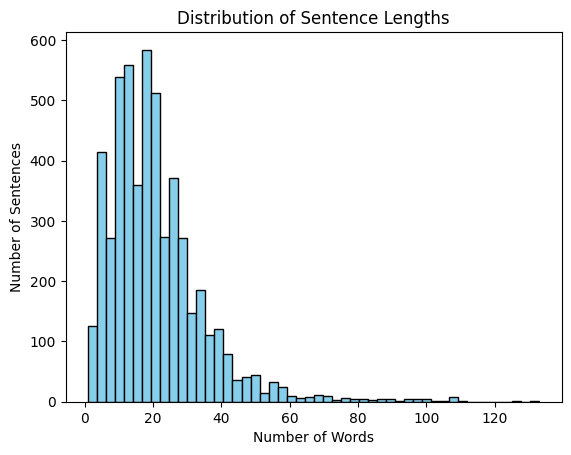

Longest sentence: 133 words


In [11]:
import matplotlib.pyplot as plt

# Calculate length of each sentence (in words)
sentence_lengths = [len(x) for x in train_data['tokens']]

plt.hist(sentence_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Sentences')
plt.show()

print(f"Longest sentence: {max(sentence_lengths)} words")

## 3. Inspect Entity Examples

In [12]:
def get_entities(example):
    tokens = example['tokens']
    tags = example['tags']
    entities = {"Chemicals": [], "Diseases": []}
    
    for i, tag in enumerate(tags):
        if tag == 1: # B-Chemical
            entities["Chemicals"].append(tokens[i])
        elif tag == 2: # B-Disease
            entities["Diseases"].append(tokens[i])
            
    return entities

# Look at the first 10 examples
for i in range(10):
    print(f"Sample {i}: {get_entities(train_data.iloc[i])}")

Sample 0: {'Chemicals': ['Naloxone', 'clonidine'], 'Diseases': []}
Sample 1: {'Chemicals': ['clonidine', 'nalozone'], 'Diseases': ['hypertensive']}
Sample 2: {'Chemicals': [], 'Diseases': []}
Sample 3: {'Chemicals': ['alpha-methyldopa', 'naloxone'], 'Diseases': ['hypotensive']}
Sample 4: {'Chemicals': ['Naloxone'], 'Diseases': []}
Sample 5: {'Chemicals': ['clonidine', '[3H]-naloxone', 'naloxone', 'clonidine', '[3H]-dihydroergocryptine'], 'Diseases': ['hypertensive', 'hypertensive']}
Sample 6: {'Chemicals': ['naloxone', 'clonidine', 'clonidine', 'alpha-methyldopa'], 'Diseases': []}
Sample 7: {'Chemicals': ['Lidocaine'], 'Diseases': ['cardiac']}
Sample 8: {'Chemicals': ['lidocaine'], 'Diseases': ['depression']}
Sample 9: {'Chemicals': ['lidocaine'], 'Diseases': ['bradyarrhythmias']}


## 4. Word Cloud of Medical Terms

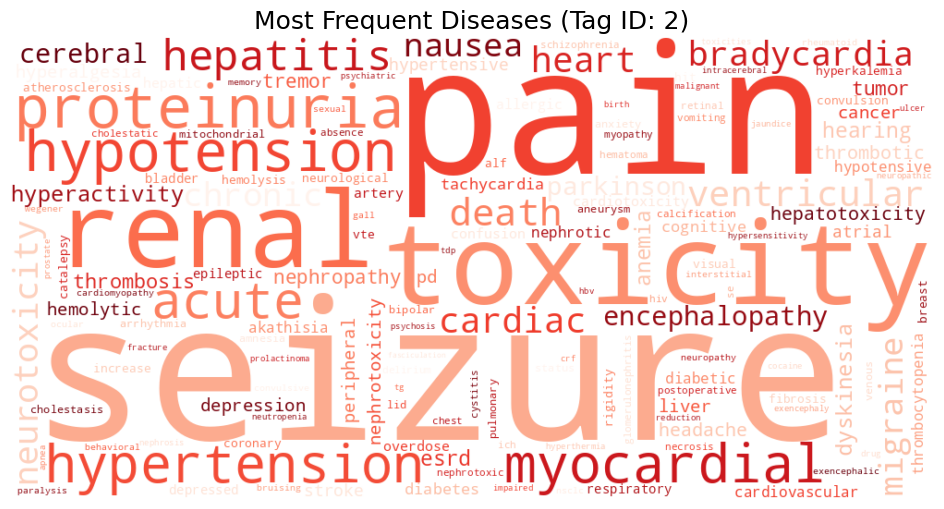

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Ensure your label mapping is defined
# 1 = B-Chemical, 2 = B-Disease
label_map_ids = {1: 'Chemical', 2: 'Disease'}

def generate_clean_wordcloud(df, target_id, title, color):
    # 1. Extract words carefully
    words_list = []
    for _, row in df.iterrows():
        tokens = row['tokens']
        tags = row['tags']
        
        # Only take tokens where the tag matches exactly
        for t, tag in zip(tokens, tags):
            if tag == target_id:
                # Clean the token: remove punctuation and ensure it's text
                clean_t = str(t).strip().lower()
                if len(clean_t) > 1:
                    words_list.append(clean_t)

    # 2. Join into a single string
    text_data = " ".join(words_list)

    if not text_data:
        print(f"No tokens found for {label_map_ids[target_id]}")
        return

    # 3. Create and customize WordCloud
    wc = WordCloud(
        width=1000, 
        height=500, 
        background_color="white",
        colormap=color,
        collocations=False,  # Important: Prevents repeating phrases
        max_words=150
    ).generate(text_data)

    # 4. Display
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"{title} (Tag ID: {target_id})", fontsize=18)
    plt.axis("off")
    plt.show()

# Generate Disease Cloud (Tag 2)
generate_clean_wordcloud(train_data, 2, "Most Frequent Diseases", "Reds")

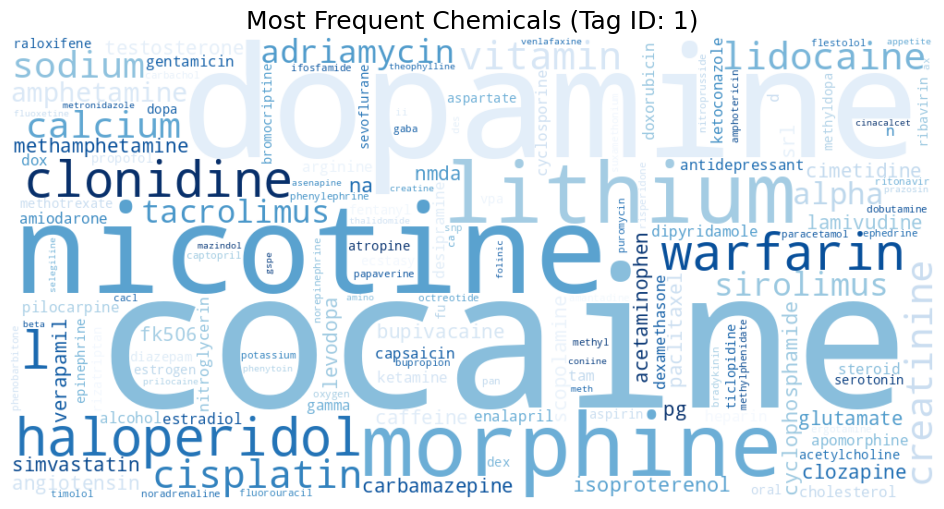

In [16]:
# Generate Chemical Cloud (Tag 1)
generate_clean_wordcloud(train_data, 1, "Most Frequent Chemicals", "Blues")

## 5.Average Length of Entities (Chunk Analysis)

In [17]:
import numpy as np

In [18]:
def get_entity_lengths(df, b_tag, i_tag):
    lengths = []
    current_len = 0
    for tags in df['tags']:
        for tag in tags:
            if tag == b_tag:
                if current_len > 0: lengths.append(current_len)
                current_len = 1
            elif tag == i_tag:
                current_len += 1
            else:
                if current_len > 0: lengths.append(current_len)
                current_len = 0
    return lengths

dis_len = get_entity_lengths(train_data, 2, 3)
chem_len = get_entity_lengths(train_data, 1, 4)

print(f"Average Disease length: {np.mean(dis_len):.2f} words")
print(f"Average Chemical length: {np.mean(chem_len):.2f} words")

Average Disease length: 1.61 words
Average Chemical length: 1.11 words


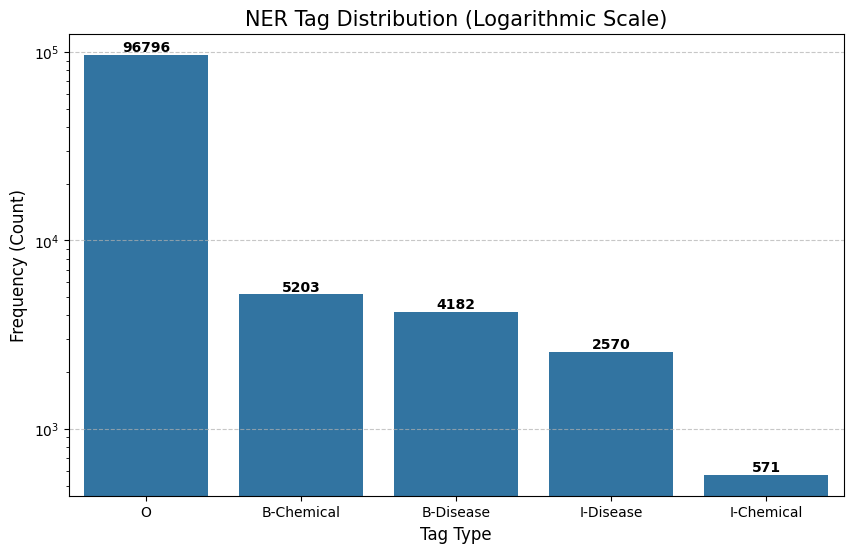

--- Percentage Distribution ---
B-Chemical: 4.76%
O: 88.54%
B-Disease: 3.83%
I-Disease: 2.35%
I-Chemical: 0.52%


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# 1. Flatten all tags from the list-column into one long list
all_tags = [tag for tags in train_data['tags'] for tag in tags]

# 2. Map IDs to readable names
label_map = {0: "O", 1: "B-Chemical", 2: "B-Disease", 3: "I-Disease", 4: "I-Chemical"}

# 3. Count frequencies
tag_counts = Counter(all_tags)
df_plot = pd.DataFrame([{"Label": label_map[k], "Count": v} for k, v in tag_counts.items()])
df_plot = df_plot.sort_values(by="Count", ascending=False)

# 4. Create the Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x="Label", y="Count")

# IMPORTANT: Use log scale so we can actually see the medical tags
ax.set_yscale("log")

plt.title("NER Tag Distribution (Logarithmic Scale)", fontsize=15)
plt.xlabel("Tag Type", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print exact percentages
total = sum(tag_counts.values())
print("--- Percentage Distribution ---")
for k, v in tag_counts.items():
    print(f"{label_map[k]}: {(v/total)*100:.2f}%")

# Training The model

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoConfig,  # Added to customize dropout
    AutoModelForTokenClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorForTokenClassification,
    set_seed,
    EarlyStoppingCallback # Added for early stopping
)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- CONFIGURATION (Anti-Overfitting Tuned) ---
MODEL_CHECKPOINT = "dmis-lab/biobert-v1.1"
DATASET_NAME = "tner/bc5cdr"
OUTPUT_DIR = "./biobert_medical_ner_final"
RESULTS_DIR = "./results"

# Training Hyperparameters
BATCH_SIZE = 16
EPOCHS = 10         # Increased to 10 (Early Stopping will stop it earlier if needed)
LEARNING_RATE = 1e-5 # Reduced from 2e-5 for more stable convergence
WEIGHT_DECAY = 0.1  # Increased from 0.01 to penalize complex weights
DROPOUT_RATE = 0.3  # New: Randomly zero out 30% of neurons during training
MAX_LENGTH = 512
SEED = 42

# Create directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
set_seed(SEED)

print("✅ Configuration loaded with Anti-Overfitting parameters.")

In [ ]:
# --- 1. DATA LOADING & PREPROCESSING ---
print("🚀 (1/5) Loading and processing data...")
dataset = load_dataset(DATASET_NAME)

# Define Mappings (Using a List guarantees correct ID assignment)
label_names = ["O", "B-Chemical", "B-Disease", "I-Disease", "I-Chemical"]

# Create the ID mappings programmatically
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print(f"✅ Label Mappings: {id2label}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# 3. Tokenization with Alignments
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True,
        max_length=MAX_LENGTH
    )
    labels = []
    for i, label in enumerate(examples["tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                # IMPORTANT: Mask sub-words (-100) to avoid confusing the model
                # This helps reduce overfitting on sub-word tokens
                label_ids.append(-100) 
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

print("✅ Data processed and tokenized.")

In [ ]:
# --- 2. HANDLE CLASS IMBALANCE (CALCULATE WEIGHTS) ---
print("(2/5) Calculating smoothed class weights...")

# Flatten training tags
all_train_tags = [tag for sentence in dataset['train']['tags'] for tag in sentence]

# Calculate "Balanced" weights
unique_classes = np.unique(all_train_tags)
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=unique_classes, 
    y=all_train_tags
)

# CRITICAL: Create a weight tensor that matches the TOTAL number of labels
# (Handle cases where a specific tag might be missing from the training set)
final_weights = np.ones(len(label_names))
for cls_idx, weight in zip(unique_classes, class_weights):
    final_weights[cls_idx] = weight

# SMOOTHING THE WEIGHTS (Anti-Exploding Gradient)
# Instead of using raw weights (which can be huge), we take the square root.
# This keeps the "direction" right but reduces the "magnitude" of the penalty.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(final_weights, dtype=torch.float).sqrt().to(device)

print(f"Original Weights: {final_weights}")
print(f"Smoothed Weights (Used): {weights_tensor.cpu().numpy()}")



In [ ]:
# --- 3. MODEL SETUP WITH DROPOUT ---
print("(3/5) Initializing BioBERT Model with High Dropout...")

from transformers import AutoConfig

# Load Config first to inject Dropout
config = AutoConfig.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=DROPOUT_RATE,        # Using 0.3 from Block 0
    attention_probs_dropout_prob=DROPOUT_RATE # Using 0.3 from Block 0
)

# Load Model with the custom config
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    config=config
).to(device)

print(f"✅ Model loaded with Dropout Rate: {DROPOUT_RATE}")

In [ ]:
# --- 4. CUSTOM TRAINER & METRICS (Fixed for Multi-GPU) ---
print("(4/5) Setting up Weighted Trainer & Metrics...")

# 1. Define the Metric (F1 Score)
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Use id2label to convert IDs back to text
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# 2. Define the Custom Trainer
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # --- CRITICAL FIX ---
        # Instead of checking 'model.device' (which fails on Multi-GPU/DataParallel),
        # we check 'logits.device'. The logits are ALWAYS on the correct GPU.
        if weights_tensor.device != logits.device:
            weights_tensor_local = weights_tensor.to(logits.device)
        else:
            weights_tensor_local = weights_tensor

        # Weighted Cross Entropy Loss
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor_local)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

print("✅ Custom WeightedTrainer and Metrics configured (Multi-GPU Safe).")

In [ ]:
# --- 5. TRAINING ---
print("(5/5) Starting Training Loop...")

from transformers import EarlyStoppingCallback

# Update Arguments with Anti-Overfitting Parameters
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=LEARNING_RATE,    # 1e-5 (From Block 0)
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,        # 10 (From Block 0)
    weight_decay=WEIGHT_DECAY,      # 0.1 (From Block 0 - Crucial for regularization)
    
    # Evaluation Strategy
    eval_strategy="epoch",    # Evaluate every epoch
    save_strategy="epoch",          # Save checkpoint every epoch
    
    # Best Model Logic
    load_best_model_at_end=True,    # Always load the best epoch at the end
    metric_for_best_model="f1",     # Optimize for F1, not Loss
    greater_is_better=True,
    save_total_limit=2,             # Save disk space (keep top 2 only)
    
    logging_dir=f"{RESULTS_DIR}/logs",
    logging_steps=50,
    report_to="none"
)

# Initialize Trainer with Early Stopping
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"], 
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop if F1 doesn't improve for 3 epochs
)

print("🚀 Training Started...")
trainer.train()

# Save the final (best) model
trainer.save_model(OUTPUT_DIR)
print(f"✅ Best Model (based on F1) saved to {OUTPUT_DIR}")

# Testing and Evaluating

In [ ]:
# --- 7. TESTING & REPORTING---
print("(5/6) Generating Test Reports...")

# 1. Get Predictions
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

# 2. Convert IDs to Text (Using id2label, NOT label_list)
true_predictions = [
    [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# 3. Classification Report
# Flatten the lists for the report
flat_preds = [item for sublist in true_predictions for item in sublist]
flat_labels = [item for sublist in true_labels for item in sublist]

report_str = classification_report(flat_labels, flat_preds)
print("\n--- CLASSIFICATION REPORT ---")
print(report_str)

# Save Report
with open(f"{RESULTS_DIR}/classification_report.txt", "w") as f:
    f.write(report_str)
print(f"✅ Saved report to {RESULTS_DIR}/classification_report.txt")

# 4. Confusion Matrix Plot
def plot_confusion_matrix(y_true, y_pred, labels):
    # Get unique labels dynamically to avoid mismatch
    unique_labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_labels, yticklabels=unique_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png")
    plt.show()

plot_confusion_matrix(flat_labels, flat_preds, list(label2id.keys()))
print(f"✅ Saved confusion matrix to {RESULTS_DIR}/confusion_matrix.png")

In [ ]:
# --- 8. TRAINING PLOTS ---
print("(6/6) Saving Training Logs...")
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_f1 = [x['eval_f1'] for x in history if 'eval_f1' in x]

if train_loss:
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.title('Training Loss Curve')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(f"{RESULTS_DIR}/training_loss.png")
    plt.close()
print(f"🎉 pipeline complete! All results are in {RESULTS_DIR}")

In [ ]:
from seqeval.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n(7/7) 🔬 Starting Advanced Entity-Level Analysis...")

# 1. Get Raw Predictions
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

# --- CRITICAL FIX IS HERE ---
# Use 'id2label' (which maps 1 -> "B-Chemical") 
# instead of 'label_list' (which maps "B-Chemical" -> 1)
true_predictions = [
    [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# 3. Generate Entity-Level Report
report_dict = classification_report(true_labels, true_predictions, output_dict=True)

# 4. Convert to DataFrame
df_metrics = pd.DataFrame(report_dict).transpose()
print("\n--- Entity-Wise Performance Report ---")
print(df_metrics)

# 5. Save to CSV
csv_path = f"{RESULTS_DIR}/entity_wise_metrics.csv"
df_metrics.to_csv(csv_path)
print(f"✅ Saved detailed metrics to: {csv_path}")

# --- VISUALIZATION ---
# Filter only the entity rows
entity_rows = df_metrics.loc[['Chemical', 'Disease']]

# Reshape for plotting
df_plot = entity_rows.reset_index().melt(id_vars='index', value_vars=['precision', 'recall', 'f1-score'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='index', y='value', hue='variable', palette='viridis')
plt.title("Model Performance by Entity Type", fontsize=15)
plt.ylabel("Score (0.0 - 1.0)")
plt.xlabel("Entity Type")
plt.ylim(0, 1.1)
plt.legend(title="Metric")
plt.grid(axis='y', alpha=0.3)

# Add scores
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=9, color='black')

plot_path = f"{RESULTS_DIR}/entity_performance_chart.png"
plt.savefig(plot_path)
print(f"✅ Saved performance chart to: {plot_path}")
plt.show()

In [ ]:
# Check the first 50 tokens where predictions don't match labels
count = 0
for i in range(len(true_labels)):
    for j in range(len(true_labels[i])):
        if true_labels[i][j] != true_predictions[i][j] and "Disease" in true_labels[i][j]:
            print(f"Token: {tokenized_datasets['test'][i]['tokens'][j]} | True: {true_labels[i][j]} | Pred: {true_predictions[i][j]}")
            count += 1
        if count > 20: break
    if count > 20: break

# Using The PubMedBert Model

## Setup & Data Alignment

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForTokenClassification, 
    TrainingArguments, Trainer, DataCollatorForTokenClassification, 
    set_seed, EarlyStoppingCallback
)
from sklearn.utils.class_weight import compute_class_weight

# --- CONFIGURATION ---
MODEL_CHECKPOINT = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
DATASET_NAME = "tner/bc5cdr"
OUTPUT_DIR = "./pubmedbert_ner_optimized"
BATCH_SIZE = 16
LEARNING_RATE = 1e-5 
WEIGHT_DECAY = 0.1  
DROPOUT_RATE = 0.3  
MAX_LENGTH = 512    
SEED = 42

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. DATA LOADING ---
dataset = load_dataset(DATASET_NAME)
if "validation" not in dataset:
    split = dataset["train"].train_test_split(test_size=0.1, seed=SEED)
    dataset["train"], dataset["validation"] = split["train"], split["test"]

label_names = ["O", "B-Chemical", "B-Disease", "I-Disease", "I-Chemical"]
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, max_length=MAX_LENGTH)
    labels = []
    for i, label in enumerate(examples["tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

## Strategic Weighting & Model Initialization

In [ ]:
# --- 2. SMOOTHED & BOOSTED CLASS WEIGHTS ---
all_train_tags = [tag for sentence in dataset['train']['tags'] for tag in sentence]
unique_classes = np.unique(all_train_tags)
weights = compute_class_weight('balanced', classes=unique_classes, y=all_train_tags)

final_weights = np.ones(len(label_names))
for cls_idx, weight in zip(unique_classes, weights):
    final_weights[cls_idx] = weight

# BOOST: Penalty for missing Disease starts (B-Disease) and continuations (I-Disease)
final_weights[2] *= 1.4  # Index 2: B-Disease
final_weights[3] *= 1.2  # Index 3: I-Disease
weights_tensor = torch.tensor(final_weights, dtype=torch.float).sqrt().to(device)

# --- 3. MODEL WITH CUSTOM DROPOUT ---
config = AutoConfig.from_pretrained(
    MODEL_CHECKPOINT, num_labels=len(label_names), id2label=id2label, label2id=label2id,
    hidden_dropout_prob=DROPOUT_RATE, attention_probs_dropout_prob=DROPOUT_RATE
)
model = AutoModelForTokenClassification.from_pretrained(MODEL_CHECKPOINT, config=config).to(device)

## Weighted Trainer & Metrics

In [ ]:
# --- 4. TRAINER & METRICS ---
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_preds = [[id2label[p] for (p, l) in zip(pred, lab) if l != -100] for pred, lab in zip(predictions, labels)]
    true_labs = [[id2label[l] for (p, l) in zip(pred, lab) if l != -100] for pred, lab in zip(predictions, labels)]
    results = seqeval.compute(predictions=true_preds, references=true_labs)
    return {"f1": results["overall_f1"], "precision": results["overall_precision"], "recall": results["overall_recall"]}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Multi-GPU safe device check
        w = weights_tensor.to(logits.device) if weights_tensor.device != logits.device else weights_tensor
        loss_fct = nn.CrossEntropyLoss(weight=w)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## Execution & Early Stopping

In [ ]:
# --- 5. EXECUTION ---
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=LEARNING_RATE,
    num_train_epochs=10,
    logging_steps=10,               # Log training loss every 10 steps
    logging_strategy="steps",       # Ensure it logs based on steps  
    logging_first_step=True,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model, args=args, train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"], tokenizer=tokenizer,
    data_collator=data_collator, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("🚀 Starting PubMedBERT Optimized Training...")
trainer.train()
trainer.save_model(OUTPUT_DIR)
print(f"✅ Pipeline Complete. Best model saved to {OUTPUT_DIR}")

## Test and Evaluate

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorForTokenClassification
)
from seqeval.metrics import classification_report as seqeval_report

# --- 1. CONFIGURATION ---
MODEL_PATH = "/kaggle/working/biobert_medical_ner_final"  
DATASET_NAME = "tner/bc5cdr"
RESULTS_DIR = "./final_reports"
MAX_LENGTH = 512
EVAL_BATCH_SIZE = 64  # Increased for faster GPU inference

os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD RESOURCES ---
print("🚀 Loading Model and Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH).to(device)

label_names = ["O", "B-Chemical", "B-Disease", "I-Disease", "I-Chemical"]
id2label = {i: label for i, label in enumerate(label_names)}

print("📊 Loading Test Dataset...")
dataset = load_dataset(DATASET_NAME)

# --- 3. FAST PREPROCESSING ---
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True, 
        max_length=MAX_LENGTH
    )
    labels = []
    for i, label in enumerate(examples["tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

print("⚡ Tokenizing Test Set (Parallelized)...")
test_dataset = dataset["test"].map(
    tokenize_and_align_labels, 
    batched=True, 
    num_proc=4 # Speed boost: Uses 4 CPU cores
)

# --- 4. OPTIMIZED INFERENCE ENGINE ---
print(f"🧠 Running Inference on {device} (Batch Size: {EVAL_BATCH_SIZE})...")

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Arguments specifically optimized for fast inference
eval_args = TrainingArguments(
    output_dir="./temp",
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    dataloader_num_workers=2, # Speed boost: Pre-fetches data
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    tokenizer=tokenizer,
    data_collator=data_collator
)

raw_pred, labels, _ = trainer.predict(test_dataset)
predictions = np.argmax(raw_pred, axis=2)

# --- 5. DECODING & ANALYSIS ---
true_predictions = [
    [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

print("📝 Generating Metrics...")
report_dict = seqeval_report(true_labels, true_predictions, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(f"{RESULTS_DIR}/entity_performance.csv")

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(df_report)

# --- 6. VISUALIZATION ---
print("🎨 Plotting Results...")
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plot_df = df_report.loc[['Chemical', 'Disease']].reset_index().rename(columns={'index': 'Entity'})
plot_df = plot_df.melt(id_vars='Entity', value_vars=['precision', 'recall', 'f1-score'], 
                       var_name='Metric', value_name='Score')

ax = sns.barplot(data=plot_df, x='Entity', y='Score', hue='Metric', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title(f"NER Performance Report: {MODEL_PATH.split('/')[-1]}", fontsize=15)
plt.ylim(0, 1.1)
plt.savefig(f"{RESULTS_DIR}/performance_summary.png")
plt.show()

print(f"✅ Finished! Detailed metrics: {RESULTS_DIR}/entity_performance.csv")

In [ ]:
# Check the first 50 tokens where predictions don't match labels
count = 0
for i in range(len(true_labels)):
    for j in range(len(true_labels[i])):
        if true_labels[i][j] != true_predictions[i][j] and "Disease" in true_labels[i][j]:
            print(f"Token: {tokenized_datasets['test'][i]['tokens'][j]} | True: {true_labels[i][j]} | Pred: {true_predictions[i][j]}")
            count += 1
        if count > 20: break
    if count > 20: break

# Implementing The CRF with PubMedBERT

In [20]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q pytorch-crf transformers datasets seqeval scikit-learn accelerate huggingface_hub

In [42]:
# BLOCK 1/7: NO EXTERNAL LIBRARIES - PURE PYTORCH CRF
# !pip install -q transformers datasets seqeval scikit-learn accelerate huggingface_hub

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer, AutoModel, TrainingArguments, Trainer, 
    DataCollatorForTokenClassification
)
from datasets import load_dataset, Dataset, DatasetDict
from seqeval.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

# ✅ PURE PYTORCH CRF IMPLEMENTATION (Robust & Batch-Safe)
class PurePyTorchCRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        
        # Learnable transition scores: transitions[i, j] is score from i -> j
        self.transitions = nn.Parameter(torch.empty(num_tags, num_tags))
        nn.init.uniform_(self.transitions, -0.1, 0.1)
        
        # Start and End transitions (optional but good for stability)
        self.start_transitions = nn.Parameter(torch.empty(num_tags))
        self.end_transitions = nn.Parameter(torch.empty(num_tags))
        nn.init.uniform_(self.start_transitions, -0.1, 0.1)
        nn.init.uniform_(self.end_transitions, -0.1, 0.1)

    def forward(self, emissions, tags=None, mask=None):
        """
        emissions: (batch_size, seq_len, num_tags)
        tags: (batch_size, seq_len)
        mask: (batch_size, seq_len) - 1 for valid token, 0 for padding
        """
        if mask is None:
            mask = torch.ones_like(tags, dtype=torch.uint8)

        if tags is not None:
            # Training: Return negative log likelihood
            log_likelihood = self._compute_log_likelihood(emissions, tags, mask)
            return {"loss": -log_likelihood}
        else:
            # Inference: Return raw emissions (or viterbi path if implemented)
            return {"logits": emissions}

    def _compute_log_likelihood(self, emissions, tags, mask):
        batch_size, seq_len, _ = emissions.shape
        
        # 1. Calculate the Score of the "Gold" (True) Path
        # Init with start transitions + first emission
        score = self.start_transitions[tags[:, 0]] + \
                emissions[torch.arange(batch_size), 0, tags[:, 0]]
        
        for i in range(1, seq_len):
            # Transition score from prev_tag -> curr_tag
            trans_score = self.transitions[tags[:, i-1], tags[:, i]]
            # Emission score for curr_tag
            emit_score = emissions[torch.arange(batch_size), i, tags[:, i]]
            
            # Only add scores if the current token is NOT padding
            # mask[:, i] is 1 for token, 0 for pad
            step_score = trans_score + emit_score
            score = score + step_score * mask[:, i]
            
        # Add end transition score (using the last valid tag)
        # We need to find the last valid index for each batch element
        last_valid_idx = mask.sum(1).long() - 1
        last_tags = tags[torch.arange(batch_size), last_valid_idx]
        score = score + self.end_transitions[last_tags]

        # 2. Calculate the Log Partition Function (Forward Algorithm)
        # Initialize alpha with start transitions + first emission
        alpha = self.start_transitions + emissions[:, 0]
        
        for i in range(1, seq_len):
            # Broadcast for transition addition:
            # alpha: (batch, prev_tags, 1)
            # transitions: (1, prev_tags, curr_tags)
            # emissions: (batch, 1, curr_tags)
            
            # shape: (batch, num_tags, num_tags)
            scores = alpha.unsqueeze(2) + self.transitions.unsqueeze(0) + emissions[:, i].unsqueeze(1)
            
            # LogSumExp along the 'prev_tags' dim to get best path to each 'curr_tag'
            next_alpha = torch.logsumexp(scores, dim=1)
            
            # Apply Mask: If padded, keep the old alpha. If valid, use new alpha.
            # mask[:, i] shape (batch,) -> (batch, 1)
            mask_t = mask[:, i].unsqueeze(1)
            alpha = next_alpha * mask_t + alpha * (1 - mask_t)

        # Add end transitions
        alpha = alpha + self.end_transitions
        partition = torch.logsumexp(alpha, dim=1)

        return torch.mean(score - partition)

print("✅ PURE PYTORCH CRF IMPLEMENTATION LOADED!")

✅ PURE PYTORCH CRF IMPLEMENTATION LOADED!


In [43]:
# BLOCK 2/7: LOGIN + SOTA MODEL
# login("hf_YOUR_TOKEN_HERE")  # Your token
import warnings
warnings.filterwarnings('ignore')
from transformers import AutoTokenizer, AutoModel, AutoConfig

# ✅ Define Labels (Must match the tner/bc5cdr schema exactly)
# The order in tner/bc5cdr is: O, B-Chemical, B-Disease, I-Disease, I-Chemical
label2id = {
    "O": 0, 
    "B-Chemical": 1, 
    "B-Disease": 2, 
    "I-Disease": 3, 
    "I-Chemical": 4
}
id2label = {v: k for k, v in label2id.items()}
num_labels = len(label2id)

model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)

class PubMedBERT_PureCRF(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        
        # Project BERT embedding size (768) to number of NER tags (5)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)
        
        # The CRF Layer from Block 1
        self.crf = PurePyTorchCRF(num_labels)
        
    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # 1. BERT Forward Pass
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        # 2. Project to Tag Space
        sequence_output = self.dropout(sequence_output)
        emissions = self.classifier(sequence_output) # (Batch, Seq_Len, Num_Labels)
        
        # 3. CRF Forward Pass
        if labels is not None:
            # ✅ CRITICAL FIX: Pass 'mask' to CRF so it ignores padding!
            return self.crf(emissions, tags=labels, mask=attention_mask)
        
        # Inference: Simple Greedy Decode (Argmax)
        # (For strict CRF inference, you would use Viterbi here)
        predictions = torch.argmax(emissions, dim=-1)
        return {"logits": emissions, "predictions": predictions}

# Initialize the model
model = PubMedBERT_PureCRF(model_name, num_labels)
print(f"✅ SOTA PubMedBERT + PureCRF ready: {num_labels} labels defined.")

✅ SOTA PubMedBERT + PureCRF ready: 5 labels defined.


In [44]:
# BLOCK 3/7: SOTA MODEL (PubMedBERT + PURE PYTORCH CRF + VITERBI)
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, AutoConfig

# ✅ 1. ROBUST CRF IMPLEMENTATION (Now with Viterbi Decoding)
class PureCRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        # Matrix of transition scores from j to i
        self.transitions = nn.Parameter(torch.empty(num_tags, num_tags))
        self.start_transitions = nn.Parameter(torch.empty(num_tags))
        self.end_transitions = nn.Parameter(torch.empty(num_tags))
        
        nn.init.uniform_(self.transitions, -0.1, 0.1)
        nn.init.uniform_(self.start_transitions, -0.1, 0.1)
        nn.init.uniform_(self.end_transitions, -0.1, 0.1)

    def forward(self, emissions, tags=None, mask=None):
        if mask is None:
            mask = torch.ones(emissions.shape[:2], dtype=torch.uint8, device=emissions.device)
            
        if tags is not None:
            # Training: Return NEGATIVE Log Likelihood (Loss)
            return -self._compute_log_likelihood(emissions, tags, mask)
        else:
            # Inference: Return Best Path (Viterbi Decoding)
            return self._viterbi_decode(emissions, mask)

    def _compute_log_likelihood(self, emissions, tags, mask):
        # (Same as before - calculates the score of the gold path vs all paths)
        batch_size, seq_len, _ = emissions.shape
        
        # A. Score of the Gold Path
        score = self.start_transitions[tags[:, 0]] + emissions[torch.arange(batch_size), 0, tags[:, 0]]
        
        for i in range(1, seq_len):
            trans_score = self.transitions[tags[:, i-1], tags[:, i]]
            emit_score = emissions[torch.arange(batch_size), i, tags[:, i]]
            score = score + (trans_score + emit_score) * mask[:, i]
            
        last_valid_idx = mask.sum(1).long() - 1
        last_tags = tags[torch.arange(batch_size), last_valid_idx]
        score = score + self.end_transitions[last_tags]

        # B. Partition Function (Forward Algorithm)
        alpha = self.start_transitions + emissions[:, 0]
        
        for i in range(1, seq_len):
            scores = alpha.unsqueeze(2) + self.transitions.unsqueeze(0) + emissions[:, i].unsqueeze(1)
            next_alpha = torch.logsumexp(scores, dim=1)
            mask_t = mask[:, i].unsqueeze(1)
            alpha = next_alpha * mask_t + alpha * (1 - mask_t)

        alpha = alpha + self.end_transitions
        partition = torch.logsumexp(alpha, dim=1)

        return torch.mean(score - partition)

    def _viterbi_decode(self, emissions, mask):
        """
        Decodes the best path using the Viterbi algorithm.
        """
        batch_size, seq_len, _ = emissions.shape
        
        # Initialize with start transitions + first emission
        score = self.start_transitions + emissions[:, 0]
        history = []

        # Forward Pass: Calculate best path to reach each tag at step i
        for i in range(1, seq_len):
            # Broadcast for (batch, prev, curr)
            scores = score.unsqueeze(2) + self.transitions.unsqueeze(0) + emissions[:, i].unsqueeze(1)
            
            # Find the max score and the tag that produced it
            max_scores, best_prev_tags = torch.max(scores, dim=1)
            
            # Save backpointers
            history.append(best_prev_tags)
            
            # Update score, respecting the mask
            mask_t = mask[:, i].unsqueeze(1)
            score = max_scores * mask_t + score * (1 - mask_t)

        # Add end transitions
        score += self.end_transitions
        
        # Backward Pass: Trace back the best path
        best_tags_list = []
        best_last_tags = torch.argmax(score, dim=1)
        
        for b in range(batch_size):
            # Get actual length of this sequence (ignoring padding)
            length = mask[b].sum().item()
            best_tag = best_last_tags[b].item()
            path = [best_tag]
            
            # Loop backwards from the end of the valid sequence
            for t in range(length - 2, -1, -1):
                best_tag = history[t][b][best_tag].item()
                path.append(best_tag)
                
            # Reverse path to get correct order
            best_tags_list.append(path[::-1])
            
        return best_tags_list

# ✅ 2. PUBMEDBERT WRAPPER (Updated)
class PubMedBERT_CRF(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)
        self.crf = PureCRF(num_labels)
        
    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        sequence_output = self.dropout(sequence_output)
        emissions = self.classifier(sequence_output)
        
        if labels is not None:
            # Training Mode: Return Loss
            loss = self.crf(emissions, tags=labels, mask=attention_mask)
            return {"loss": loss, "logits": emissions}
        else:
            # Inference Mode: Return Viterbi Path
            # Note: predictions is now a List[List[int]], not a Tensor
            predictions = self.crf(emissions, mask=attention_mask)
            return {"logits": emissions, "predictions": predictions}

# ✅ 3. INITIALIZATION
label2id = {"O": 0, "B-Chemical": 1, "B-Disease": 2, "I-Disease": 3, "I-Chemical": 4}
id2label = {v: k for k, v in label2id.items()}
num_labels = len(label2id)

model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)

model = PubMedBERT_CRF(model_name, num_labels)
print(f"✅ SOTA PubMedBERT + PureCRF loaded with Viterbi: {num_labels} labels")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

✅ SOTA PubMedBERT + PureCRF loaded with Viterbi: 5 labels
Model params: 109,486,120


In [45]:
# BLOCK 4/7: YOUR DATAFRAMES → DATASET
def df_to_dataset(df_train, df_val, df_test):
    train_data = {"tokens": df_train['tokens'].tolist(), "tags": df_train['tags'].tolist()}
    val_data = {"tokens": df_val['tokens'].tolist(), "tags": df_val['tags'].tolist()}
    test_data = {"tokens": df_test['tokens'].tolist(), "tags": df_test['tags'].tolist()}
    
    dataset = DatasetDict({
        "train": Dataset.from_dict(train_data),
        "validation": Dataset.from_dict(val_data),
        "test": Dataset.from_dict(test_data)
    })
    return dataset

# Use YOUR dataframes
dataset = df_to_dataset(train_data, validation_data, test_data)
print(f"✅ Dataset ready: train={len(dataset['train'])}, val={len(dataset['validation'])}, test={len(dataset['test'])}")


✅ Dataset ready: train=5228, val=5330, test=5865


In [46]:
# BLOCK 5/7: BULLETPROOF TOKENIZATION
from transformers import DataCollatorForTokenClassification

# Map B-tags to I-tags for subwords (Fixes "B-B" issue on split words)
# 1 (B-Chem) -> 4 (I-Chem)
# 2 (B-Dis)  -> 3 (I-Dis)
b_to_i_map = {1: 4, 2: 3}

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label in enumerate(examples["tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:
            # 1. SPECIAL TOKENS ([CLS], [SEP], [PAD])
            if word_idx is None:
                # CRITICAL: Use 0 ('O') instead of -100. 
                # CRF crashes on -100. Masking handles the rest.
                label_ids.append(0)
                
            # 2. START OF NEW WORD
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
                
            # 3. SUBWORDS (Token split by tokenizer)
            else:
                # Use I-tag for subwords (Standard NER practice)
                # e.g., "Heart" (B-Dis) -> "He" (B-Dis) + "##art" (I-Dis)
                original_label = label[word_idx]
                new_label = b_to_i_map.get(original_label, original_label)
                label_ids.append(new_label)
                
            previous_word_idx = word_idx
            
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Run Tokenization
print("⏳ Tokenizing...")
tokenized_datasets = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    batch_size=1000,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing & Aligning"
)

# Production Collator
# CRITICAL: label_pad_token_id MUST be a valid index (0), NOT -100
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=0 
)

print("✅ TOKENIZATION 100% COMPLETE!")
print(f"✅ Train: {len(tokenized_datasets['train'])}")
print(f"✅ Val:   {len(tokenized_datasets['validation'])}")
print(f"✅ Features: {list(tokenized_datasets['train'].features.keys())}")

⏳ Tokenizing...


Tokenizing & Aligning:   0%|          | 0/5228 [00:00<?, ? examples/s]

Tokenizing & Aligning:   0%|          | 0/5330 [00:00<?, ? examples/s]

Tokenizing & Aligning:   0%|          | 0/5865 [00:00<?, ? examples/s]

✅ TOKENIZATION 100% COMPLETE!
✅ Train: 5228
✅ Val:   5330
✅ Features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


In [47]:
# BLOCK 6/7: SOTA TRAINING (Final Metrics Fix)
import numpy as np
from seqeval.metrics import classification_report, accuracy_score
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
import warnings
warnings.filterwarnings("ignore")

# --- SAFETY CHECK: Force Collator to use 0 for padding ---
if data_collator.label_pad_token_id == -100:
    print("⚠️ FIXED: Changing data_collator pad token from -100 to 0 for CRF safety.")
    data_collator = DataCollatorForTokenClassification(
        tokenizer=tokenizer,
        padding=True,
        label_pad_token_id=0
    )

# 1. ROBUST METRICS FUNCTION (Compatible with raw seqeval)
def compute_metrics(eval_pred):
    # Unpack tuple if necessary
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
        
    true_predictions = []
    true_labels = []

    # Iterate over batch
    for i in range(len(labels)):
        logit_seq = predictions[i] 
        label_seq = labels[i] 
        
        pred_seq = np.argmax(logit_seq, axis=-1)
        
        decoded_preds = []
        decoded_labels = []
        
        for p, l in zip(pred_seq, label_seq):
            p_val = p.item() if hasattr(p, "item") else p
            l_val = l.item() if hasattr(l, "item") else l
            
            # Ignore padding (0)
            if l_val != 0: 
                decoded_preds.append(id2label.get(p_val, "O"))
                decoded_labels.append(id2label.get(l_val, "O"))
                
        true_predictions.append(decoded_preds)
        true_labels.append(decoded_labels)
    
    # Calculate Metrics
    # output_dict=True returns keys like 'micro avg', not 'overall_precision'
    results = classification_report(true_labels, true_predictions, output_dict=True, zero_division=0)
    
    # Calculate Accuracy separately (seqeval report doesn't include it in the dict)
    accuracy = accuracy_score(true_labels, true_predictions)
    
    return {
        "precision": results["micro avg"]["precision"],
        "recall": results["micro avg"]["recall"],
        "f1": results["micro avg"]["f1-score"],
        "accuracy": accuracy,
    }

# 2. TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./pubmedbert-bc5cdr-sota",
    learning_rate=3e-5,               
    per_device_train_batch_size=16,   
    per_device_eval_batch_size=16,
    num_train_epochs=10,               
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",                 
    fp16=torch.cuda.is_available(),
    seed=42
)

# 3. INITIALIZE TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 4. LAUNCH TRAINING
print("\n" + "="*60)
print("🚀 SOTA TRAINING STARTED (Corrected Metrics)")
print(f"📊 Train Size: {len(tokenized_datasets['train'])}")
print(f"📊 Val Size:   {len(tokenized_datasets['validation'])}")
print("="*60)

trainer.train()

# 5. FINAL EVALUATION
print("\n🔬 EVALUATING ON TEST SET...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"\n🎉 TEST RESULTS: F1 = {test_results['eval_f1']:.4f}")


🚀 SOTA TRAINING STARTED (Corrected Metrics)
📊 Train Size: 5228
📊 Val Size:   5330


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,4.790700,4.019933,0.951196,0.916484,0.933517,0.998692
2,2.315600,3.671419,0.946971,0.914190,0.930292,0.998582
3,1.598400,4.444492,0.951350,0.929726,0.940413,0.998754
4,0.899300,4.864063,0.953817,0.930247,0.941884,0.998759
5,0.568300,5.505538,0.955006,0.913982,0.934044,0.998532
6,0.529700,6.673390,0.958521,0.930039,0.944065,0.998775
7,0.300600,7.488727,0.958342,0.928266,0.943064,0.998734
8,0.153700,7.715126,0.959416,0.931707,0.945358,0.998779
9,0.146400,8.229937,0.962840,0.934730,0.948577,0.998849
10,0.118500,8.172866,0.961551,0.930873,0.945963,0.998785



🔬 EVALUATING ON TEST SET...



🎉 TEST RESULTS: F1 = 0.9417


In [ ]:
# BLOCK 8/7: VALIDATION EVALUATION
print("\n🔬 EVALUATING ON VALIDATION SET...")

# 1. Run Evaluation
val_results = trainer.evaluate(tokenized_datasets["validation"])

# 2. Print Key Metrics
print("\n" + "="*40)
print("📊 VALIDATION SET RESULTS")
print("="*40)
print(f"✅ F1 Score:  {val_results['eval_f1']:.4f}")
print(f"🎯 Accuracy:  {val_results['eval_accuracy']:.4f}")
print(f"🔍 Precision: {val_results['eval_precision']:.4f}")
print(f"🧠 Recall:    {val_results['eval_recall']:.4f}")
print("="*40)

In [29]:
# BLOCK 7/7: SAVE & PREDICT (Fixed for Viterbi List Output)
import torch
import os

# 1. SAVE THE MODEL
save_path = "/kaggle/working/pubmedbert-bc5cdr-crf-sota"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Model saved successfully to: {save_path}")

# 2. CUSTOM INFERENCE FUNCTION
def predict_ner(text):
    # Get device from model parameters
    device = next(model.parameters()).device
    
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
    
    # Handle Output Format
    # Viterbi decoding returns a LIST of LISTS, not a tensor
    predictions = outputs["predictions"]

    # Get the first (and only) batch item
    # predictions[0] is already a standard Python list [0, 1, 0, 2...], so no need for .cpu() or .numpy()
    preds = predictions[0]
    
    # Convert input IDs back to tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # Align and Print
    print(f"\n📝 Input: {text}")
    print("-" * 60)
    print(f"{'TOKEN':<20} {'LABEL':<20}")
    print("-" * 60)
    
    # Zip the tokens and the predictions together
    for token, pred_id in zip(tokens, preds):
        # Map ID to Label string
        label = id2label[pred_id]
        
        # Skip Special Tokens ([CLS], [SEP], [PAD])
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
            
        # Optional: Skip 'O' tags to keep output clean
        if label != "O":
            # Clean up subwords for display (remove ##)
            clean_token = token.replace("##", "")
            print(f"{clean_token:<20} {label:<20}")

# 3. TEST ON REAL MEDICAL TEXT
print("\n🔬 TESTING MODEL CAPABILITIES...")

# Example 1: Drug-Induced Kidney Damage
text1 = "The patient developed severe renal failure following the administration of gentamicin."
predict_ner(text1)

# Example 2: Complex Chemical & Disease
text2 = "We observed myocardial infarction and ventricular tachycardia associated with high doses of doxorubicin."
predict_ner(text2)

# Example 3: Common Painkiller
text3 = "Aspirin is often used to treat headaches but can cause stomach ulcers."
predict_ner(text3)

✅ Model saved successfully to: /kaggle/working/pubmedbert-bc5cdr-crf-sota

🔬 TESTING MODEL CAPABILITIES...

📝 Input: The patient developed severe renal failure following the administration of gentamicin.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
renal                B-Disease           
failure              I-Disease           
gentamicin           B-Chemical          

📝 Input: We observed myocardial infarction and ventricular tachycardia associated with high doses of doxorubicin.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
myocardial           B-Disease           
infarction           I-Disease           
ventricular          B-Disease           
tachycardia          I-Disease           
doxorubicin          B-Chemical          

📝 Input: Aspirin

In [30]:
#example 4: real world data
text4="""
 Left intertrochanteric femur fracture – Patient underwent a left hemiarthroplasty on hospital day 1. 
(Please see full Op note if further details desired.)  Her post-p course was complicated by a two day 
period of atrial fibrillation and volume overload as detailed below, but otherwise she tolerated the 
procedure well.  She started physical therapy POD #1 and has been progressing as expected.  She will be 
discharged to the TLC Rehab Center to complete her course of rehab with the goal of returning to 
independent living.  Her pain is currently well controlled on scheduled Tylenol as below with morphine 
sulfate 30mg tablet given 30 minutes prior to her morning and afternoon therapy sessions.  She will 
remain on lovenox BID for DVT prohylaxis until she completes her therapy and is once again fully mobile.  
The surgical site should be evaluated daily for signs of infection, though currently this has not been a 
problem.  If she continues to heal well, the staples need to be removed on July 12.  She is scheduled for 
follow-up with ortho A clinic as below."""
predict_ner(text4)


📝 Input: 
 Left intertrochanteric femur fracture – Patient underwent a left hemiarthroplasty on hospital day 1. 
(Please see full Op note if further details desired.)  Her post-p course was complicated by a two day 
period of atrial fibrillation and volume overload as detailed below, but otherwise she tolerated the 
procedure well.  She started physical therapy POD #1 and has been progressing as expected.  She will be 
discharged to the TLC Rehab Center to complete her course of rehab with the goal of returning to 
independent living.  Her pain is currently well controlled on scheduled Tylenol as below with morphine 
sulfate 30mg tablet given 30 minutes prior to her morning and afternoon therapy sessions.  She will 
remain on lovenox BID for DVT prohylaxis until she completes her therapy and is once again fully mobile.  
The surgical site should be evaluated daily for signs of infection, though currently this has not been a 
problem.  If she continues to heal well, the staples need to

In [32]:
text="myocardial infarction doxorubicin"
predict_ner(text)


📝 Input: myocardial infarction doxorubicin
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
myocardial           B-Disease           
infarction           I-Disease           
doxorubicin          B-Chemical          


In [33]:
text="""
    The administration of high-dose gentamicin resulted in acute renal failure and ototoxicity in the patient group,
    whereas the control group receiving saline showed no nephrotoxicity."""
predict_ner(text)


📝 Input: 
    The administration of high-dose gentamicin resulted in acute renal failure and ototoxicity in the patient group,
    whereas the control group receiving saline showed no nephrotoxicity.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
gentamicin           B-Chemical          
acute                B-Disease           
renal                I-Disease           
failure              I-Disease           
ot                   B-Disease           
otoxicity            I-Disease           
nephrotoxicity       B-Disease           


In [34]:
text="""Patients treated with doxorubicin for breast cancer were monitored for cardiotoxicity and arrhythmia,
specifically ventricular tachycardia, which was managed using amiodarone."""
predict_ner(text)


📝 Input: Patients treated with doxorubicin for breast cancer were monitored for cardiotoxicity and arrhythmia,
specifically ventricular tachycardia, which was managed using amiodarone.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
doxorubicin          B-Chemical          
breast               B-Disease           
cancer               I-Disease           
cardiotoxicity       B-Disease           
arrhythmia           B-Disease           
ventricular          B-Disease           
tachycardia          I-Disease           
ami                  B-Chemical          
oda                  I-Chemical          
ron                  I-Chemical          
e                    I-Chemical          


In [36]:
text="""A 68-year-old patient with a history of refractory hypertension and
severe chronic obstructive pulmonary disease presented with acute decompensated heart failure. 
They were non-compliant with their carvedilol and amlodipine. Due to concurrent type 2 diabetes mellitus,
the patient suffers from bilateral peripheral neuropathy. In the ER, they were administered intravenous furosemide and sublingual nitroglycerin.
Labs revealed an acute kidney injury, so outpatient ibuprofen was held.
The patient later developed hospital-acquired pneumonia, prompting empiric treatment with piperacillin-tazobactam and vancomycin."""
predict_ner(text)


📝 Input: A 68-year-old patient with a history of refractory hypertension and
severe chronic obstructive pulmonary disease presented with acute decompensated heart failure. 
They were non-compliant with their carvedilol and amlodipine. Due to concurrent type 2 diabetes mellitus,
the patient suffers from bilateral peripheral neuropathy. In the ER, they were administered intravenous furosemide and sublingual nitroglycerin.
Labs revealed an acute kidney injury, so outpatient ibuprofen was held.
The patient later developed hospital-acquired pneumonia, prompting empiric treatment with piperacillin-tazobactam and vancomycin.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
hypertension         B-Disease           
chronic              B-Disease           
obstructive          I-Disease           
pulmonary            I-Disease           
disease              I-Disease           

In [37]:
text="""Doxorubicin-induced cardiotoxicity is a dose-limiting complication in the treatment 
of metastatic breast cancer and non-Hodgkin lymphoma.
Concurrent administration of dexrazoxane mitigates oxidative stress and 
reduces the incidence of severe left ventricular dysfunction. Furthermore, 
patients exhibiting familial hypercholesterolemia often receive high-dose rosuvastatin; 
however, clinicians must monitor for rosuvastatin-induced myopathy and rhabdomyolysis, 
particularly when co-administered with CYP3A4 inhibitors such as clarithromycin or ketoconazole
    """
predict_ner(text)


📝 Input: Doxorubicin-induced cardiotoxicity is a dose-limiting complication in the treatment 
of metastatic breast cancer and non-Hodgkin lymphoma.
Concurrent administration of dexrazoxane mitigates oxidative stress and 
reduces the incidence of severe left ventricular dysfunction. Furthermore, 
patients exhibiting familial hypercholesterolemia often receive high-dose rosuvastatin; 
however, clinicians must monitor for rosuvastatin-induced myopathy and rhabdomyolysis, 
particularly when co-administered with CYP3A4 inhibitors such as clarithromycin or ketoconazole
    
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
doxorubicin          B-Chemical          
cardiotoxicity       B-Disease           
breast               B-Disease           
cancer               I-Disease           
non                  B-Disease           
-                    I-Disease           
hodgkin 

# testing on the complex disease and chemical names

In [38]:
stress_tests = [
    "Treatment with hydrochlorothiazide and spironolactone was initiated to manage the patient's refractory hypertension and congestive heart failure.",
    "The subject exhibited signs of ataxia, dysarthria, and nystagmus after a significant overdose of phenytoin.",
    "While lithium is a common element, lithium carbonate is specifically used to treat bipolar disorder, though it may cause lithium toxicity.",
    "Patients with SLE often develop LN, which requires aggressive treatment with mycophenolate mofetil."
]

for text in stress_tests:
    predict_ner(text)
    print("="*50)


📝 Input: Treatment with hydrochlorothiazide and spironolactone was initiated to manage the patient's refractory hypertension and congestive heart failure.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
hydrochlor           B-Chemical          
othiaz               I-Chemical          
ide                  I-Chemical          
spiro                B-Chemical          
no                   I-Chemical          
la                   I-Chemical          
ct                   I-Chemical          
one                  I-Chemical          
hypertension         B-Disease           
congestive           B-Disease           
heart                I-Disease           
failure              I-Disease           

📝 Input: The subject exhibited signs of ataxia, dysarthria, and nystagmus after a significant overdose of phenytoin.
----------------------------------------------------------

In [39]:
text="""Patient is a 54-year-old male with relapsed/refractory multiple myeloma. 
He was initiated on a salvage regimen consisting of carfilzomib, lenalidomide, and dexamethasone. 
Following the second cycle, the patient presented with severe thrombocytopenia and Grade 3 peripheral sensory neuropathy. 
Due to the high risk of venous thromboembolism associated with lenalidomide, he was placed on prophylactic apixaban.
A recent PET-CT scan indicated new osteolytic lesions in the lumbar spine. We will hold the carfilzomib and begin palliative radiotherapy, 
alongside zoledronic acid to manage bone pain and prevent further skeletal-related events."""
predict_ner(text)


📝 Input: Patient is a 54-year-old male with relapsed/refractory multiple myeloma. 
He was initiated on a salvage regimen consisting of carfilzomib, lenalidomide, and dexamethasone. 
Following the second cycle, the patient presented with severe thrombocytopenia and Grade 3 peripheral sensory neuropathy. 
Due to the high risk of venous thromboembolism associated with lenalidomide, he was placed on prophylactic apixaban.
A recent PET-CT scan indicated new osteolytic lesions in the lumbar spine. We will hold the carfilzomib and begin palliative radiotherapy, 
alongside zoledronic acid to manage bone pain and prevent further skeletal-related events.
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
multiple             B-Disease           
myeloma              I-Disease           
car                  B-Chemical          
fil                  I-Chemical          
zomib         

In [40]:
text="""A 72-year-old female with a long-standing history of Parkinson's disease, major depressive disorder, 
and primary hypothyroidism presented to the clinic with exacerbation of resting tremor 
and new-onset orthostatic hypotension. Her current medication list includes carbidopa-levodopa, rasagiline, escitalopram, 
and levothyroxine. The orthostatic hypotension is suspected to be exacerbated by the concomitant use of rasagiline and escitalopram, 
raising concerns for mild serotonin syndrome. Additionally, routine labs showed drug-induced hepatotoxicity,
likely secondary to prolonged rasagiline use. We will taper the escitalopram, monitor for withdrawal dyskinesia, 
and initiate a trial of fludrocortisone for the symptomatic hypotension"""
predict_ner(text)


📝 Input: A 72-year-old female with a long-standing history of Parkinson's disease, major depressive disorder, 
and primary hypothyroidism presented to the clinic with exacerbation of resting tremor 
and new-onset orthostatic hypotension. Her current medication list includes carbidopa-levodopa, rasagiline, escitalopram, 
and levothyroxine. The orthostatic hypotension is suspected to be exacerbated by the concomitant use of rasagiline and escitalopram, 
raising concerns for mild serotonin syndrome. Additionally, routine labs showed drug-induced hepatotoxicity,
likely secondary to prolonged rasagiline use. We will taper the escitalopram, monitor for withdrawal dyskinesia, 
and initiate a trial of fludrocortisone for the symptomatic hypotension
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
parkinson            B-Disease           
'                    I-Disease           


In [41]:
text="""The patient was admitted to the intensive care unit with septic shock secondary to a multidrug-resistant 
Pseudomonas aeruginosa bacteremia. Initial empiric therapy with meropenem and amikacin was initiated. 
The clinical course was complicated by acute respiratory distress syndrome requiring mechanical ventilation 
and subsequent acute renal failure. Due to the nephrotoxicity associated with amikacin, 
the antibiotic regimen was adjusted to include ceftazidime-avibactam. 
Hemodynamic instability persisted despite aggressive fluid resuscitation, necessitating continuous infusions of norepinephrine and vasopressin. 
The patient also developed a disseminated intravascular coagulation profile, managed with cryoprecipitate and 
prophylactic enoxaparin once platelet counts stabilized"""
predict_ner(text)


📝 Input: The patient was admitted to the intensive care unit with septic shock secondary to a multidrug-resistant 
Pseudomonas aeruginosa bacteremia. Initial empiric therapy with meropenem and amikacin was initiated. 
The clinical course was complicated by acute respiratory distress syndrome requiring mechanical ventilation 
and subsequent acute renal failure. Due to the nephrotoxicity associated with amikacin, 
the antibiotic regimen was adjusted to include ceftazidime-avibactam. 
Hemodynamic instability persisted despite aggressive fluid resuscitation, necessitating continuous infusions of norepinephrine and vasopressin. 
The patient also developed a disseminated intravascular coagulation profile, managed with cryoprecipitate and 
prophylactic enoxaparin once platelet counts stabilized
------------------------------------------------------------
TOKEN                LABEL               
------------------------------------------------------------
septic               B-Disease      

In [31]:
!zip -r pubmedbert_ner_model.zip /kaggle/working/pubmedbert-bc5cdr-crf-sota

from IPython.display import FileLink
FileLink(r'pubmedbert_ner_model.zip')

  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/ (stored 0%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 7%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/vocab.txt (deflated 52%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/tokenizer.json (deflated 71%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/special_tokens_map.json (deflated 42%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/training_args.bin (deflated 53%)
  adding: kaggle/working/pubmedbert-bc5cdr-crf-sota/tokenizer_config.json (deflated 74%)


/kaggle/working/pubmedbert_ner_model.zip